In [1]:
import pandas as pd

weather = pd.read_csv("../data/raw/delhi_weather_raw.csv", parse_dates=["date"])
aq = pd.read_csv("../data/raw/delhi_air_quality_raw.csv", parse_dates=["datetime"])
fires_pb = pd.read_csv("../data/processed/fires_punjab_haryana.csv", parse_dates=["acq_date"])

print("Weather:", weather.shape)
print("Air quality:", aq.shape)
print("Fires:", fires_pb.shape)

Weather: (1826, 5)
Air quality: (29976, 3)
Fires: (40747, 15)


In [2]:
aq = aq.dropna()   

aq["date"] = pd.to_datetime(aq["datetime"].dt.date)   

aq_daily = aq.groupby("date")[["pm2_5", "pm10"]].mean().reset_index()

print(aq_daily.shape)
aq_daily.head()

(1246, 3)


,date,pm2_5,pm10
0,2022-08-04,43.594737,63.178947
1,2022-08-05,43.929167,63.750000
2,2022-08-06,73.745833,107.050000
3,2022-08-07,42.170833,61.029167
4,2022-08-08,52.733333,75.850000


In [3]:
fire_daily = (
    fires_pb
    .groupby("acq_date")
    .agg(
        fire_count=("latitude", "size"),
        fire_frp=("frp", "sum")
    )
    .reset_index()
    .rename(columns={"acq_date": "date"})
)

print(fire_daily.shape)
fire_daily.sort_values("fire_count", ascending=False).head(10)

(758, 3)


,date,fire_count,fire_frp
210,2022-11-11,1402,19499.7
201,2022-11-02,1337,16569.2
459,2023-11-15,1165,14756.4
203,2022-11-04,1122,15214.6
452,2023-11-08,993,12445.2
208,2022-11-09,809,11245.3
445,2023-11-01,776,8903.7
447,2023-11-03,751,8775.7
199,2022-10-31,688,11281.0
720,2024-11-18,676,8397.1


In [4]:
df = aq_daily.merge(weather, on="date", how="inner")
df = df.merge(fire_daily, on="date", how="left")

df[["fire_count", "fire_frp"]] = df[["fire_count", "fire_frp"]].fillna(0)

df = df[(df["date"] >= "2022-08-04") & (df["date"] <= "2024-12-31")]
df = df.reset_index(drop=True)

print(df.shape)
print(df.isna().sum())
df.head()

(881, 9)
date              0
pm2_5             0
pm10              0
temp_mean         0
rain_mm           0
wind_speed_max    0
wind_dir          0
fire_count        0
fire_frp          0
dtype: int64


,date,pm2_5,pm10,temp_mean,rain_mm,wind_speed_max,wind_dir,fire_count,fire_frp
0,2022-08-04,43.594737,63.178947,28.1,1.7,14.0,105,0.0,0.0
1,2022-08-05,43.929167,63.750000,27.6,5.7,13.2,110,0.0,0.0
2,2022-08-06,73.745833,107.050000,28.7,1.9,6.3,140,1.0,21.2
3,2022-08-07,42.170833,61.029167,27.7,18.6,13.8,111,1.0,3.7
4,2022-08-08,52.733333,75.850000,29.0,0.2,7.9,92,4.0,178.3


In [5]:
df.to_csv("../data/processed/delhi_daily_combined.csv", index=False)
print("Saved!")

Saved!


In [6]:
monthly = df.groupby(df["date"].dt.month)[["fire_count", "pm2_5"]].mean().round(1)
print(df.shape)
print(monthly)

(881, 9)
      fire_count  pm2_5
date                   
1            4.2  119.9
2            4.2   70.4
3            3.1   59.0
4            4.4   42.9
5          104.0   54.3
6           14.0   50.9
7            1.1   43.1
8            0.9   42.8
9            1.2   50.8
10          69.5   71.8
11         217.6  105.4
12           8.1   99.9


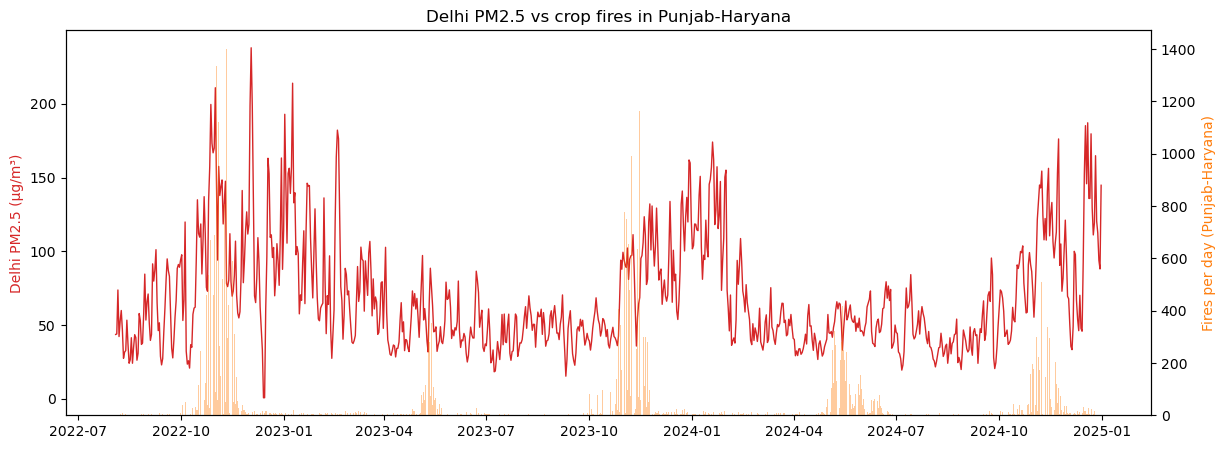

In [7]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14, 5))

# Line: Delhi PM2.5
ax1.plot(df["date"], df["pm2_5"], color="tab:red", linewidth=1)
ax1.set_ylabel("Delhi PM2.5 (µg/m³)", color="tab:red")

# Bars: Punjab-Haryana fires
ax2 = ax1.twinx()
ax2.bar(df["date"], df["fire_count"], color="tab:orange", alpha=0.4)
ax2.set_ylabel("Fires per day (Punjab-Haryana)", color="tab:orange")

plt.title("Delhi PM2.5 vs crop fires in Punjab-Haryana")
plt.show()

In [8]:
lowest = df.nsmallest(5, "pm2_5")
lowest[["date", "pm2_5", "pm10", "rain_mm", "wind_speed_max"]]

,date,pm2_5,pm10,rain_mm,wind_speed_max
132,2022-12-14,0.620833,0.895833,0.0,19.4
133,2022-12-15,0.658333,0.929167,0.0,17.1
402,2023-09-10,15.275000,21.604167,35.3,17.6
338,2023-07-08,18.245833,26.087500,34.4,21.9
339,2023-07-09,18.787500,26.820833,29.7,16.5


In [9]:
import numpy as np

bad_days = df["date"].isin(["2022-12-14", "2022-12-15"])
df.loc[bad_days, ["pm2_5", "pm10"]] = np.nan

df[["pm2_5", "pm10"]] = df[["pm2_5", "pm10"]].interpolate()

print(df.loc[130:135, ["date", "pm2_5", "pm10"]])

          date      pm2_5        pm10
130 2022-12-12  46.962500   78.029167
131 2022-12-13  33.041667   53.966667
132 2022-12-14  42.430556   67.090278
133 2022-12-15  51.819444   80.213889
134 2022-12-16  61.208333   93.337500
135 2022-12-17  96.187500  144.870833


/var/folders/jl/xfkzgh1j7_91ppxwqtyxx3v80000gn/T/ipykernel_80964/2930183750.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  bad_days = df["date"].isin(["2022-12-14", "2022-12-15"])


In [10]:
season = df[df["date"].dt.month.isin([10, 11])].copy()

season["wind_from_pb"] = season["wind_dir"].between(260, 360)
season["many_fires"] = season["fire_count"] > 200

summary = (
    season
    .groupby(["many_fires", "wind_from_pb"])["pm2_5"]
    .agg(["mean", "count"])
    .round(1)
)
summary

mean  count
many_fires wind_from_pb              
False      False          94.9     40
           True           78.1    104
True       False         122.0     14
           True          101.7     25

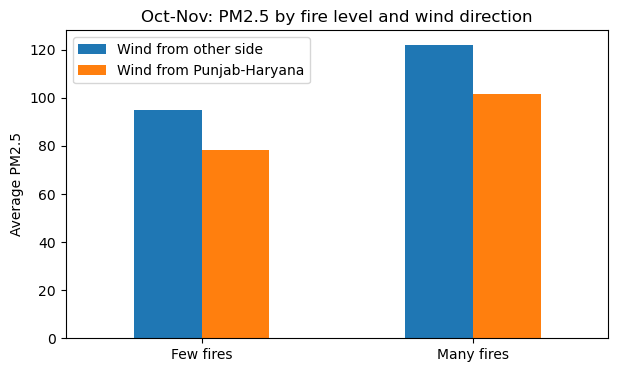

In [13]:
labels = summary["mean"].unstack()
labels.index = ["Few fires", "Many fires"]
labels.columns = ["Wind from other side", "Wind from Punjab-Haryana"]

labels.plot(kind="bar", figsize=(7, 4))
plt.ylabel("Average PM2.5")
plt.title("Oct-Nov: PM2.5 by fire level and wind direction")
plt.xticks(rotation=0)
plt.show()

In [14]:
season.groupby("wind_from_pb")["wind_speed_max"].mean().round(1)

wind_from_pb
False    11.5
True     12.9
Name: wind_speed_max, dtype: float64

In [15]:
in_season = df["date"].dt.month.isin([10, 11])

for lag in [0, 1, 2, 3]:
    fires_before = df["fire_count"].shift(lag)
    c = df.loc[in_season, "pm2_5"].corr(fires_before[in_season])
    print(f"Fires {lag} day(s) before -> correlation with today's PM2.5: {c:.2f}")

Fires 0 day(s) before -> correlation with today's PM2.5: 0.28
Fires 1 day(s) before -> correlation with today's PM2.5: 0.29
Fires 2 day(s) before -> correlation with today's PM2.5: 0.32
Fires 3 day(s) before -> correlation with today's PM2.5: 0.32


In [16]:
df["pm25_tomorrow"] = df["pm2_5"].shift(-1)
data = df.dropna(subset=["pm25_tomorrow"]).copy()

train = data[data["date"].dt.year < 2024]
test = data[data["date"].dt.year == 2024]

print("Train days:", len(train))
print("Test days:", len(test))

Train days: 515
Test days: 365


In [22]:
from sklearn.metrics import mean_absolute_error

baseline_pred = test["pm2_5"]   # andaza: kal = aaj
mae_baseline = mean_absolute_error(test["pm25_tomorrow"], baseline_pred)
print(f"Baseline MAE (full 2024): {mae_baseline:.1f}")

winter = test["date"].dt.month.isin([10, 11, 12])
mae_winter = mean_absolute_error(test.loc[winter, "pm25_tomorrow"], baseline_pred[winter])
print(f"Baseline MAE (Oct-Dec 2024): {mae_winter:.1f}")


Baseline MAE (full 2024): 12.1
Baseline MAE (Oct-Dec 2024): 18.7


In [23]:
import numpy as np

# 1. Yesterday's PM2.5 (captures the pollution trend)
df["pm25_yesterday"] = df["pm2_5"].shift(1)

# 2. Total fires over the last 3 days (smoke takes time to reach Delhi)
df["fires_3day"] = df["fire_count"].rolling(3).sum()

# 3. Convert wind direction to sin/cos (so 359° and 1° are treated as close)
df["wind_sin"] = np.sin(np.radians(df["wind_dir"]))
df["wind_cos"] = np.cos(np.radians(df["wind_dir"]))

# 4. Convert month to sin/cos (so December and January are treated as close)
month = df["date"].dt.month
df["month_sin"] = np.sin(2 * np.pi * month / 12)
df["month_cos"] = np.cos(2 * np.pi * month / 12)

In [25]:
# Features the model will use as input
features = [
    "pm2_5", "pm25_yesterday", "pm10",
    "temp_mean", "rain_mm", "wind_speed_max", "wind_sin", "wind_cos",
    "fire_count", "fires_3day",
    "month_sin", "month_cos"
]

# Drop rows where any feature or the target is missing
data = df.dropna(subset=features + ["pm25_tomorrow"]).copy()

# Time-based split: learn from 2022-2023, test on 2024
train = data[data["date"].dt.year < 2024]
test = data[data["date"].dt.year == 2024]

X_train, y_train = train[features], train["pm25_tomorrow"]
X_test, y_test = test[features], test["pm25_tomorrow"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (513, 12)
X_test: (365, 12)


In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Train the model on 2022-2023 data
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict tomorrow's PM2.5 for every day in 2024
lr_pred = lr.predict(X_test)

# Winter mask: October to December
winter = (test["date"].dt.month.isin([10, 11, 12])).values

# Baseline on the same test set: tomorrow = today
baseline_pred = X_test["pm2_5"].values

# Compare errors (lower is better)
results = pd.DataFrame({
    "Model": ["Baseline (tomorrow = today)", "Linear Regression"],
    "MAE full 2024": [
        mean_absolute_error(y_test, baseline_pred),
        mean_absolute_error(y_test, lr_pred),
    ],
    "MAE Oct-Dec": [
        mean_absolute_error(y_test[winter], baseline_pred[winter]),
        mean_absolute_error(y_test[winter], lr_pred[winter]),
    ],
}).round(1)

results

,Model,MAE full 2024,MAE Oct-Dec
0,Baseline (tomorrow = today),12.1,18.7
1,Linear Regression,13.2,18.5


In [28]:
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

os.makedirs("../reports", exist_ok=True)   # folder for charts and results

# Baseline: tomorrow = today
baseline_pred = X_test["pm2_5"].values

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Random Forest: 300 decision trees, averaged together
rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Winter mask: October to December
winter = (test["date"].dt.month.isin([10, 11, 12])).values

# Compare all models (lower MAE is better)
results = pd.DataFrame({
    "Model": ["Baseline (tomorrow = today)", "Linear Regression", "Random Forest"],
    "MAE full 2024": [
        mean_absolute_error(y_test, baseline_pred),
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred),
    ],
    "MAE Oct-Dec": [
        mean_absolute_error(y_test[winter], baseline_pred[winter]),
        mean_absolute_error(y_test[winter], lr_pred[winter]),
        mean_absolute_error(y_test[winter], rf_pred[winter]),
    ],
}).round(1)

results.to_csv("../reports/model_results.csv", index=False)
results

,Model,MAE full 2024,MAE Oct-Dec
0,Baseline (tomorrow = today),12.1,18.7
1,Linear Regression,13.2,18.5
2,Random Forest,12.0,17.3


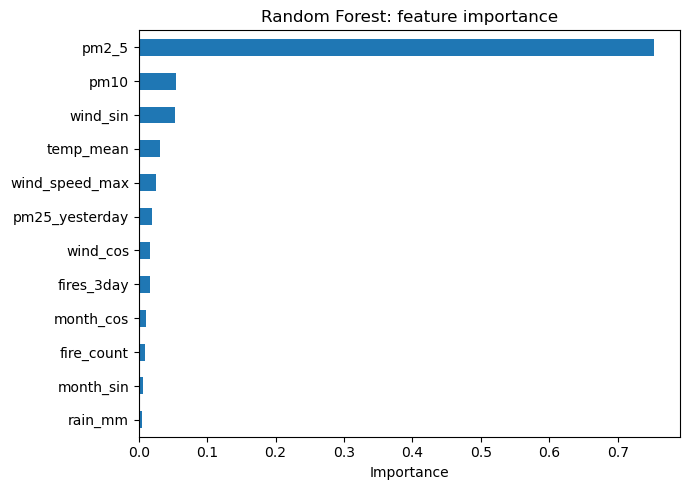

In [29]:
# How much each feature helped the Random Forest
importances = pd.Series(rf.feature_importances_, index=features).sort_values()

importances.plot(kind="barh", figsize=(7, 5), color="tab:blue")
plt.title("Random Forest: feature importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../reports/feature_importance.png", dpi=150)
plt.show()

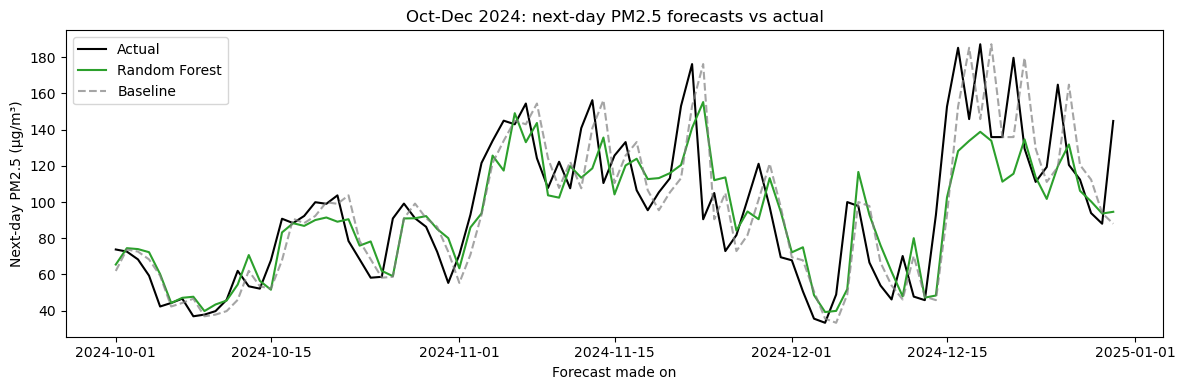

In [30]:
# Actual vs predicted PM2.5 for Oct-Dec 2024
plot_df = test[["date"]].copy()
plot_df["actual"] = y_test.values
plot_df["baseline"] = baseline_pred
plot_df["random_forest"] = rf_pred
w = plot_df[plot_df["date"].dt.month.isin([10, 11, 12])]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(w["date"], w["actual"], color="black", label="Actual")
ax.plot(w["date"], w["random_forest"], color="tab:green", label="Random Forest")
ax.plot(w["date"], w["baseline"], color="tab:gray", linestyle="--", alpha=0.7, label="Baseline")
ax.set_ylabel("Next-day PM2.5 (µg/m³)")
ax.set_xlabel("Forecast made on")
ax.set_title("Oct-Dec 2024: next-day PM2.5 forecasts vs actual")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/forecast_vs_actual.png", dpi=150)
plt.show()

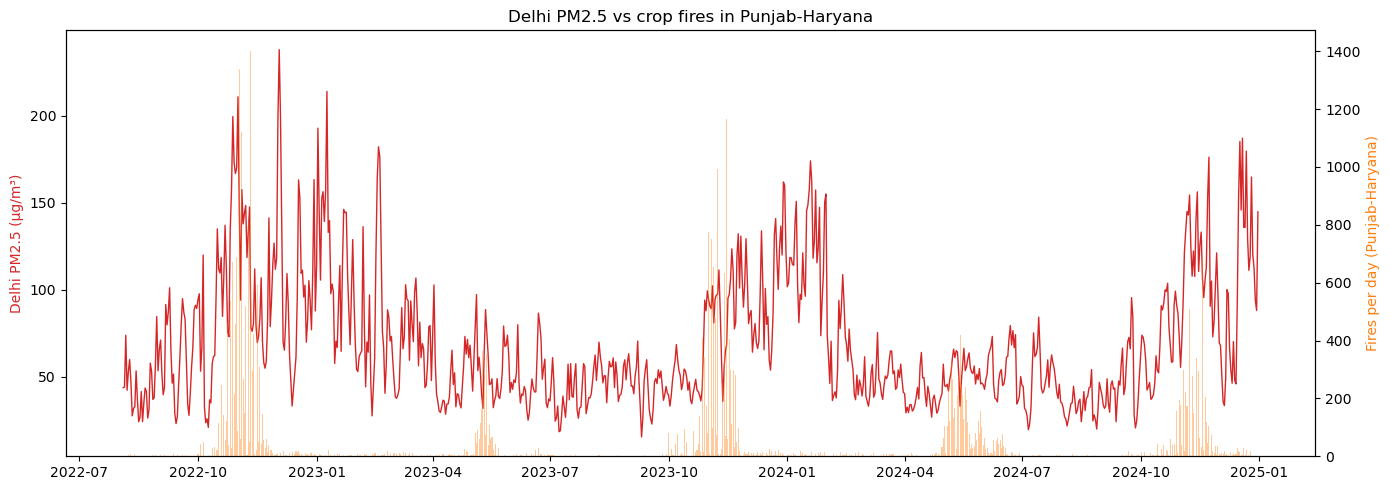

In [31]:
# Timeline chart: Delhi PM2.5 vs Punjab-Haryana fires
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(df["date"], df["pm2_5"], color="tab:red", linewidth=1)
ax1.set_ylabel("Delhi PM2.5 (µg/m³)", color="tab:red")

ax2 = ax1.twinx()
ax2.bar(df["date"], df["fire_count"], color="tab:orange", alpha=0.4)
ax2.set_ylabel("Fires per day (Punjab-Haryana)", color="tab:orange")

plt.title("Delhi PM2.5 vs crop fires in Punjab-Haryana")
plt.tight_layout()
plt.savefig("../reports/pm25_vs_fires.png", dpi=150)
plt.show()

In [32]:
# Second check: train until June 2023, test on July-December 2023
cut = "2023-07-01"
tr = data[data["date"] < cut]
te = data[(data["date"] >= cut) & (data["date"] < "2024-01-01")]

X_tr, y_tr = tr[features], tr["pm25_tomorrow"]
X_te, y_te = te[features], te["pm25_tomorrow"]

lr2 = LinearRegression().fit(X_tr, y_tr)
rf2 = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42).fit(X_tr, y_tr)

preds = {
    "Baseline (tomorrow = today)": X_te["pm2_5"].values,
    "Linear Regression": lr2.predict(X_te),
    "Random Forest": rf2.predict(X_te),
}
winter2 = te["date"].dt.month.isin([10, 11, 12]).values

results_2023 = pd.DataFrame({
    "Model": list(preds.keys()),
    "MAE Jul-Dec 2023": [mean_absolute_error(y_te, p) for p in preds.values()],
    "MAE Oct-Dec 2023": [mean_absolute_error(y_te[winter2], p[winter2]) for p in preds.values()],
}).round(1)

print("Train days:", len(tr), "| Test days:", len(te))
results_2023

Train days: 329 | Test days: 184


,Model,MAE Jul-Dec 2023,MAE Oct-Dec 2023
0,Baseline (tomorrow = today),11.7,14.3
1,Linear Regression,11.5,13.8
2,Random Forest,14.2,15.2
